In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# Read the file manually
with open("../dataset/data.csv", "r", encoding="utf-8") as f:
    lines = f.readlines()

# Fix the header
header = lines[0].strip().strip('"').replace('""', '"').split(";")

# Split the remaining rows
data = [line.strip().split(";") for line in lines[1:]]

# Create the DataFrame
df = pd.DataFrame(data, columns=header)

# Display the first 5 rows
df.head()

,Marital status,Application mode,Application order,Course,"""Daytime/evening attendance\t""",Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.0,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666666666666666,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.0,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.4,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.0,0,13.9,-0.3,0.79,Graduate


In [10]:
df.shape

(4424, 37)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype
---  ------                                          --------------  -----
 0   Marital status                                  4424 non-null   str  
 1   Application mode                                4424 non-null   str  
 2   Application order                               4424 non-null   str  
 3   Course                                          4424 non-null   str  
 4   "Daytime/evening attendance	"                   4424 non-null   str  
 5   Previous qualification                          4424 non-null   str  
 6   Previous qualification (grade)                  4424 non-null   str  
 7   Nacionality                                     4424 non-null   str  
 8   Mother's qualification                          4424 non-null   str  
 9   Father's qualification                          4424 non-null   str  
 10 

In [13]:
df.isnull().sum()

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
"Daytime/evening attendance\t"                    0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

In [14]:
# Convert all feature columns to numeric
for col in df.columns[:-1]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Check the data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   "Daytime/evening attendance	"                   4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                          4424

In [15]:
df["Target"].value_counts()

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

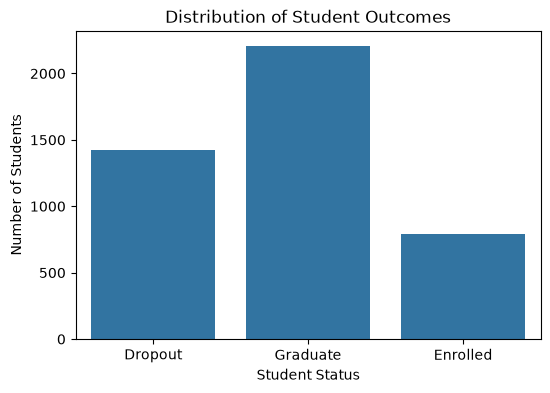

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x="Target", data=df)

plt.title("Distribution of Student Outcomes")
plt.xlabel("Student Status")
plt.ylabel("Number of Students")

plt.show()

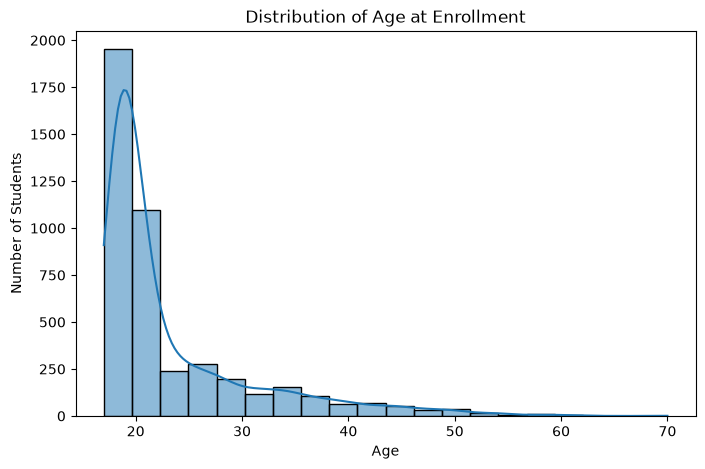

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age at enrollment"], bins=20, kde=True)

plt.title("Distribution of Age at Enrollment")
plt.xlabel("Age")
plt.ylabel("Number of Students")

plt.show()

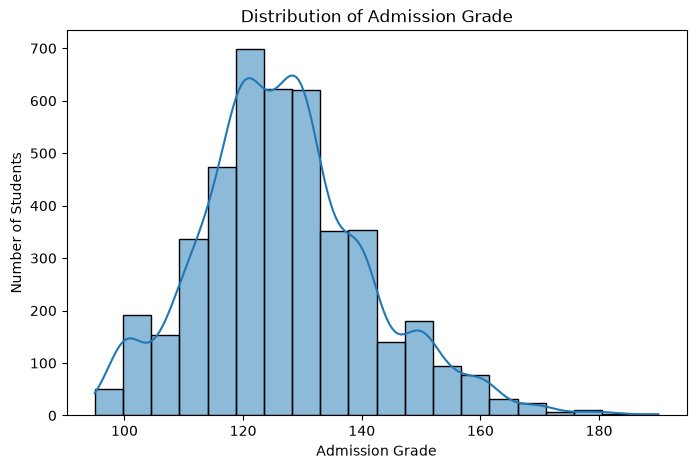

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df["Admission grade"], bins=20, kde=True)

plt.title("Distribution of Admission Grade")
plt.xlabel("Admission Grade")
plt.ylabel("Number of Students")

plt.show()

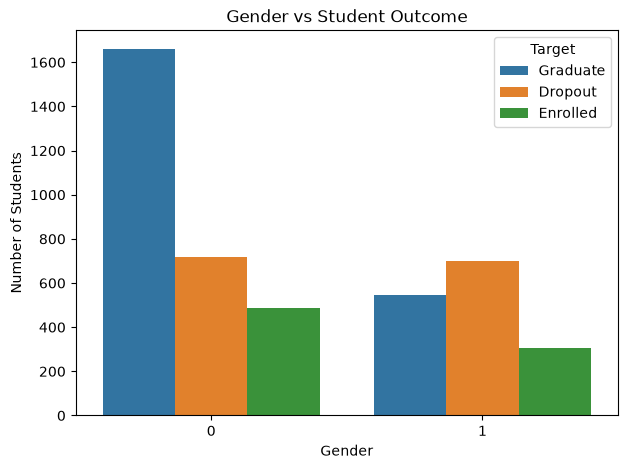

In [19]:
plt.figure(figsize=(7,5))
sns.countplot(x="Gender", hue="Target", data=df)

plt.title("Gender vs Student Outcome")
plt.xlabel("Gender")
plt.ylabel("Number of Students")

plt.show()

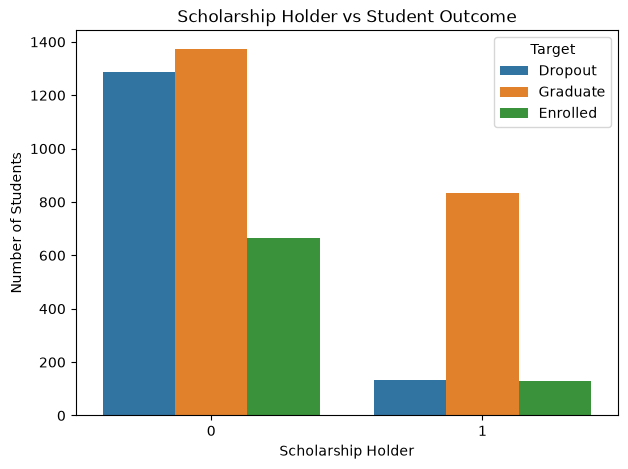

In [20]:
plt.figure(figsize=(7,5))
sns.countplot(x="Scholarship holder", hue="Target", data=df)

plt.title("Scholarship Holder vs Student Outcome")
plt.xlabel("Scholarship Holder")
plt.ylabel("Number of Students")

plt.show()

c:\Users\work\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\work\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


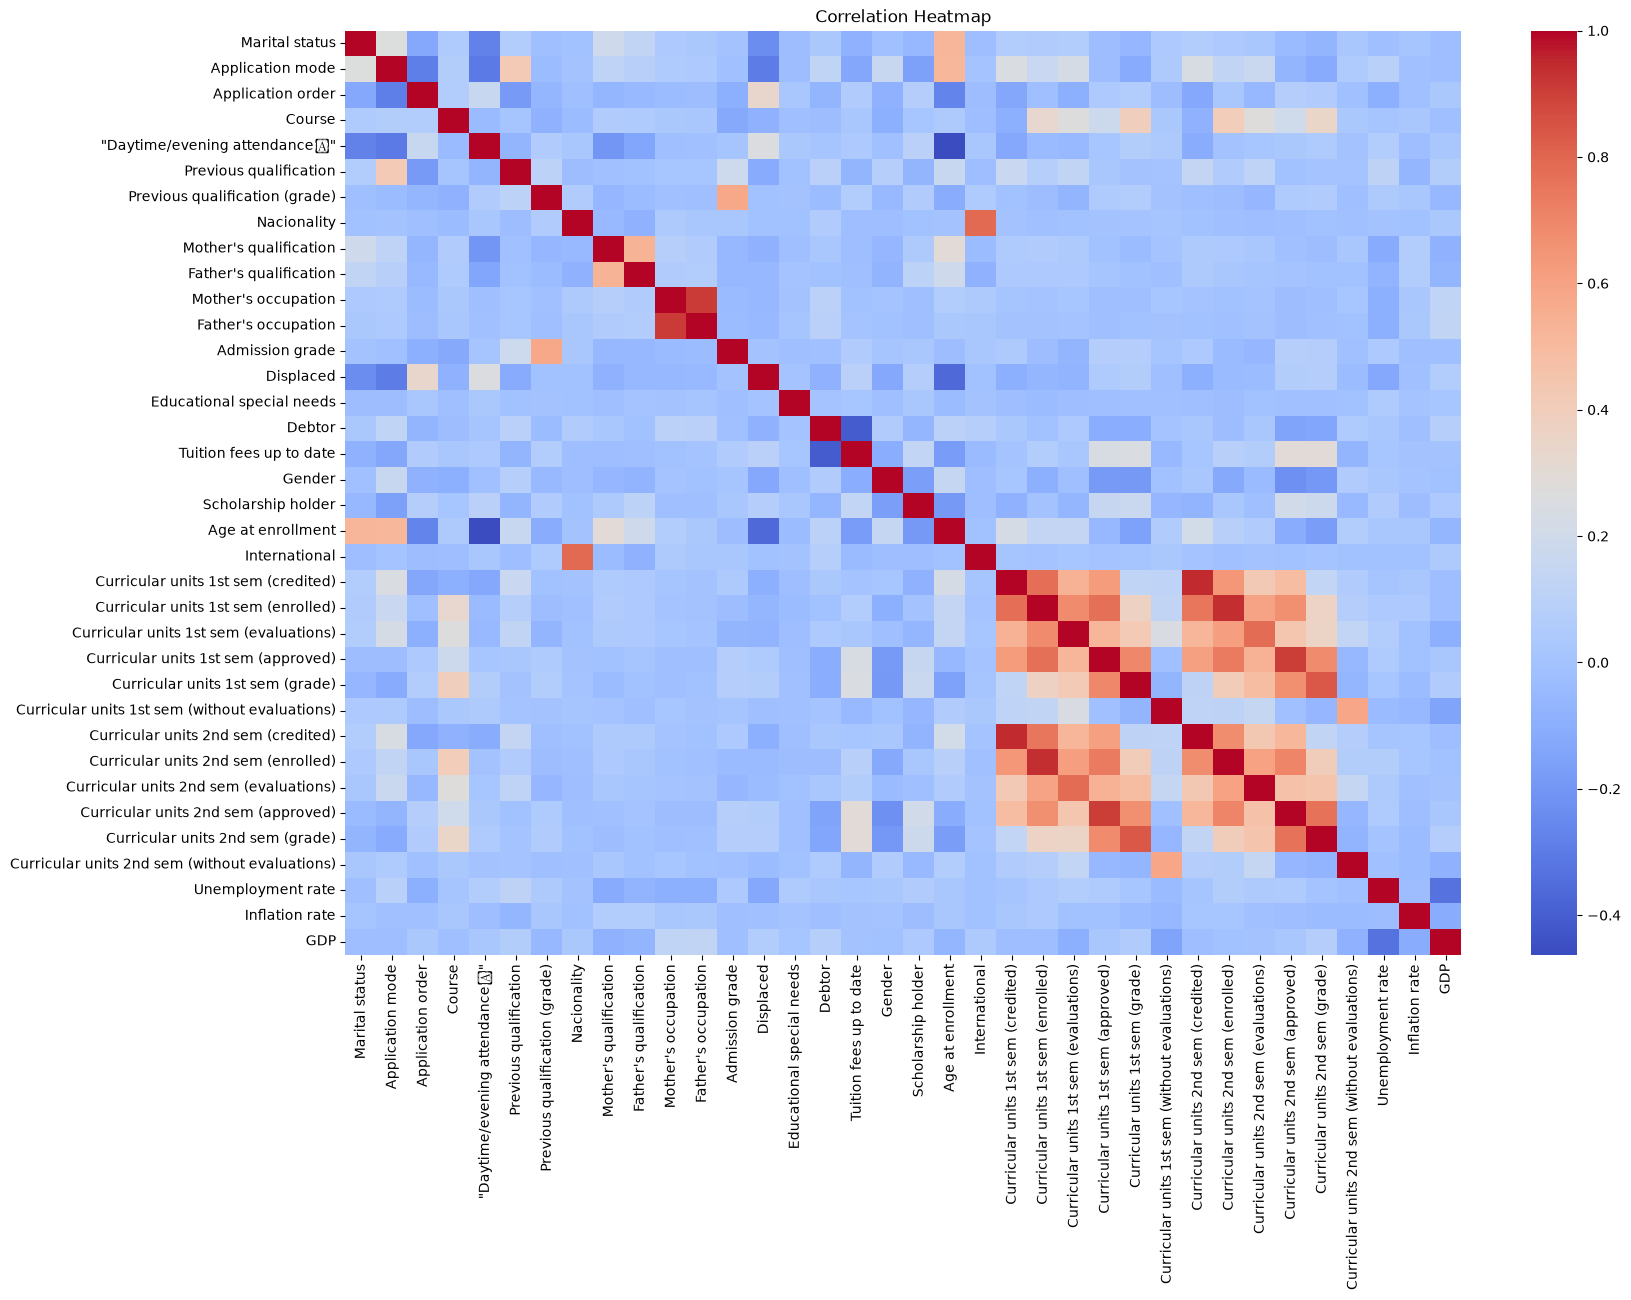

In [21]:
plt.figure(figsize=(18,12))

sns.heatmap(df.corr(numeric_only=True),
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

In [22]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df["Target"] = label_encoder.fit_transform(df["Target"])

print(label_encoder.classes_)
df["Target"].head()

['Dropout' 'Enrolled' 'Graduate']


0    0
1    2
2    0
3    2
4    2
Name: Target, dtype: int64

In [23]:
X = df.drop("Target", axis=1)
y = df["Target"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (4424, 36)
Target Shape: (4424,)


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (3539, 36)
Testing Data: (885, 36)


In [25]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

c:\Users\work\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [26]:
y_pred = log_model.predict(X_test)

print(y_pred[:10])

[0 2 2 2 0 1 2 2 2 2]


In [27]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Logistic Regression Accuracy:", accuracy)

Logistic Regression Accuracy: 0.7028248587570621


In [28]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[213  31  72]
 [ 36  35  80]
 [ 23  21 374]]


In [29]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.67      0.72       316
           1       0.40      0.23      0.29       151
           2       0.71      0.89      0.79       418

    accuracy                           0.70       885
   macro avg       0.63      0.60      0.60       885
weighted avg       0.68      0.70      0.68       885



In [30]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Create the model
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

# Make predictions
dt_pred = dt_model.predict(X_test)

# Calculate accuracy
dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.6768361581920904


In [31]:
from sklearn.metrics import classification_report

print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.73      0.64      0.68       316
           1       0.36      0.41      0.38       151
           2       0.77      0.80      0.79       418

    accuracy                           0.68       885
   macro avg       0.62      0.62      0.62       885
weighted avg       0.69      0.68      0.68       885



In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Create the Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

# Predict on test data
rf_pred = rf_model.predict(X_test)

# Calculate accuracy
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7604519774011299


In [33]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.85      0.77      0.81       316
           1       0.49      0.30      0.37       151
           2       0.76      0.92      0.83       418

    accuracy                           0.76       885
   macro avg       0.70      0.66      0.67       885
weighted avg       0.75      0.76      0.74       885



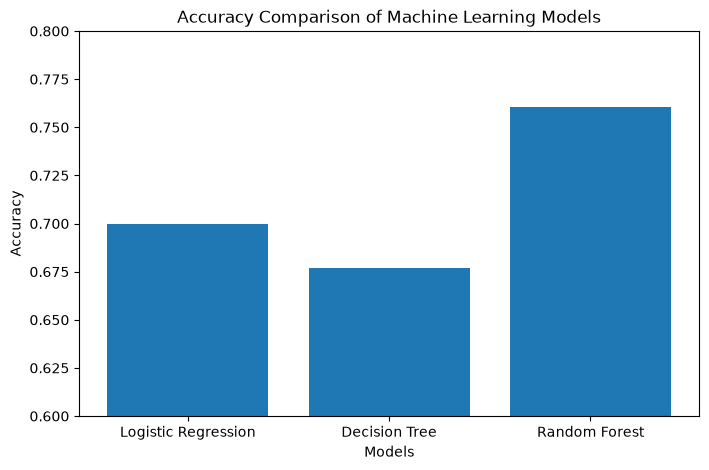

In [34]:
models = ["Logistic Regression", "Decision Tree", "Random Forest"]
accuracies = [0.70, 0.6768, 0.7605]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)

plt.title("Accuracy Comparison of Machine Learning Models")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0.6, 0.8)

plt.show()

In [35]:
import joblib

joblib.dump(rf_model, "../models/student_dropout_model.pkl")

print("Random Forest model saved successfully!")

Random Forest model saved successfully!


In [36]:
joblib.dump(label_encoder, "../models/label_encoder.pkl")

print("Label Encoder saved successfully!")

Label Encoder saved successfully!


In [37]:
selected_features = [
    "Age at enrollment",
    "Admission grade",
    "Previous qualification (grade)",
    "Gender",
    "Scholarship holder",
    "Debtor",
    "Tuition fees up to date",
    "Curricular units 1st sem (approved)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 2nd sem (grade)"
]

In [38]:
X = df[selected_features]
y = df["Target"]

print(X.head())
print("\nShape:", X.shape)

   Age at enrollment  Admission grade  Previous qualification (grade)  Gender  \
0                 20            127.3                           122.0       1   
1                 19            142.5                           160.0       1   
2                 19            124.8                           122.0       1   
3                 20            119.6                           122.0       0   
4                 45            141.5                           100.0       0   

   Scholarship holder  Debtor  Tuition fees up to date  \
0                   0       0                        1   
1                   0       0                        0   
2                   0       0                        0   
3                   0       0                        1   
4                   0       0                        1   

   Curricular units 1st sem (approved)  Curricular units 2nd sem (approved)  \
0                                    0                                    0   
1     

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [40]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [41]:
from sklearn.metrics import accuracy_score

pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.7401129943502824


In [42]:
print(X.shape)

(4424, 11)


In [43]:
rf_model.n_features_in_

11

In [44]:
import joblib

joblib.dump(rf_model, "../models/student_dropout_model.pkl")
joblib.dump(label_encoder, "../models/label_encoder.pkl")

print("Model saved successfully!")

Model saved successfully!
